In [ ]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [ ]:
#load data
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print("Trades Shape:", trades.shape)
print("Sentiment Shape:", sentiment.shape)

trades.head()
sentiment.head()

Trades Shape: (211224, 16)
Sentiment Shape: (2644, 4)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [ ]:
#data cleaning
#Convert datetime
trades['time'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce')
sentiment['Date'] = pd.to_datetime(sentiment['date'], errors='coerce')

# Extract date
trades['date'] = trades['time'].dt.date
sentiment['date'] = sentiment['Date'].dt.date

# Missing values
print(trades.isnull().sum())
print(sentiment.isnull().sum())

# Remove duplicates
trades = trades.drop_duplicates()
sentiment = sentiment.drop_duplicates()

Account                  0
Coin                     0
Execution Price          0
Size Tokens              0
Size USD                 0
Side                     0
Timestamp IST            0
Start Position           0
Direction                0
Closed PnL               0
Transaction Hash         0
Order ID                 0
Crossed                  0
Fee                      0
Trade ID                 0
Timestamp                0
time                131999
date                131999
dtype: int64
timestamp         0
value             0
classification    0
date              0
Date              0
dtype: int64


In [ ]:
#merge datasets
data = trades.merge(
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,time,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12 22:50:00,2024-02-12,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12 22:50:00,2024-02-12,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12 22:50:00,2024-02-12,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12 22:50:00,2024-02-12,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12 22:50:00,2024-02-12,Greed


In [ ]:
#feature engineering
daily_metrics = (
    data.groupby(['Account', 'date', 'classification'])
    .agg(
        daily_pnl=('Closed PnL', 'sum'),
        trades_count=('Trade ID', 'count'),
        avg_size=('Size Tokens', 'mean')
    )
    .reset_index()
)

daily_metrics.head()

,Account,date,classification,daily_pnl,trades_count,avg_size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-06-12,Greed,-175611.000056,33,9.090909
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Extreme Greed,0.000000,177,1.587571
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-03,Greed,9482.221441,45,1.318582
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-02,Greed,76710.000000,10,60.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-03-02,Fear,101011.685664,839,10.820333


In [ ]:
# long vs short ratio
long_short = data.groupby(['date', 'Side']).size().unstack(fill_value=0)

long_short['long_ratio'] = long_short['BUY'] / (long_short['BUY'] + long_short['SELL'])

long_short.head()

Side,BUY,SELL,long_ratio
date,,,
2023-01-05,3,0,1.000000
2023-05-12,7,2,0.777778
2024-01-01,10,8,0.555556
2024-01-02,6,0,1.000000
2024-01-03,37,100,0.270073


In [ ]:
# performance: fear vs greed
# Create win flag (1 = profit day, 0 = loss day)
daily_metrics['win_flag'] = (daily_metrics['daily_pnl'] > 0).astype(int)

# Win rate per trader
win_rate = (
    daily_metrics.groupby('Account')['win_flag']
    .mean()
    .reset_index(name='win_rate')
)

performance = (
    daily_metrics.groupby('classification')
    .agg(
        avg_pnl=('daily_pnl', 'mean'),
        avg_win_rate=('win_rate', 'mean'),
        avg_trade_size=('avg_size', 'mean'),
        avg_trades=('trades_count', 'mean')
    )
    .reset_index()
)

performance


,classification,avg_pnl,avg_win_rate,avg_trade_size,avg_trades
0,Extreme Fear,133.331411,0.594283,5052.867502,70.484848
1,Extreme Greed,10329.407818,0.573660,17710.032006,50.187500
2,Fear,11332.647023,0.599633,4441.295232,88.337580
3,Greed,3191.793365,0.624932,16358.123885,59.120419
4,Neutral,2017.749783,0.557681,13927.459954,74.486486


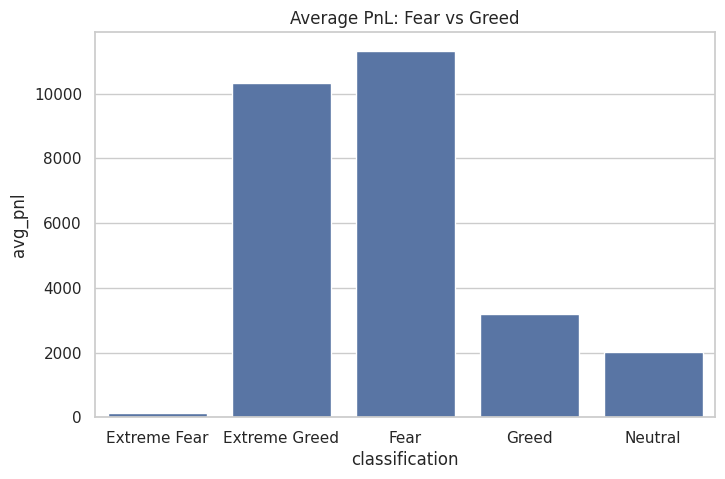

In [ ]:
#plot

plt.figure(figsize=(8,5))
sns.barplot(data=performance, x='classification', y='avg_pnl')
plt.title("Average PnL: Fear vs Greed")
plt.show()

In [ ]:
# behaviour changes
behavior = (
    data.groupby('classification')
    .agg(
        trades=('Trade ID', 'count'),
        avg_trade_size=('Size Tokens', 'mean'),
        avg_pnl=('Closed PnL', 'mean')
    )
    .reset_index()
)

behavior

,classification,trades,avg_trade_size,avg_pnl
0,Extreme Fear,2326,2460.043834,1.891632
1,Extreme Greed,5621,16407.310318,205.816345
2,Fear,13869,3219.865206,128.287950
3,Greed,11292,14956.263148,53.988003
4,Neutral,2756,17720.854908,27.088803


In [ ]:

# High vs Low size segment
data['size_segment'] = np.where(
    data['Size USD'] > data['Size USD'].median(),
    'High',
    'Low'
)

segment_perf = (
    data.groupby('size_segment')['Closed PnL']
    .mean()
    .reset_index()
)

segment_perf

,size_segment,Closed PnL
0,High,93.116556
1,Low,4.381445


In [ ]:
# frequent vs infrequent traders
freq = data.groupby('Account').size()

threshold = freq.median()

data['trader_segment'] = data['Account'].map(
    lambda x: 'Frequent' if freq[x] > threshold else 'Infrequent'
)

data[['Account', 'trader_segment']].head()

,Account,trader_segment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent


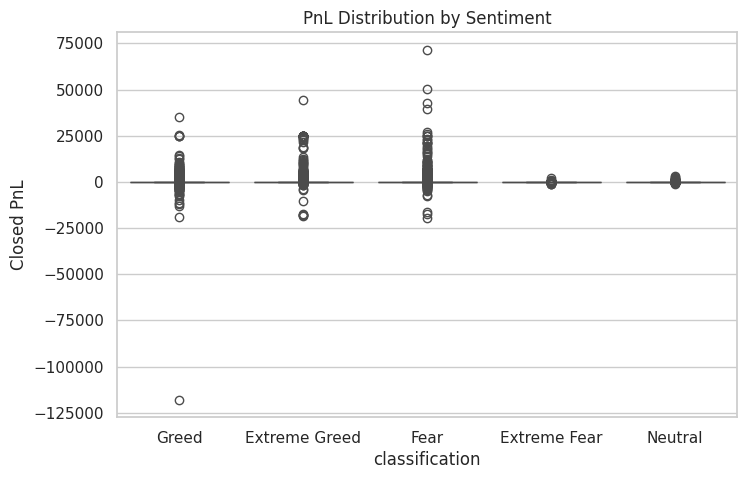

In [ ]:
#insighnt visuals
plt.figure(figsize=(8,5))
sns.boxplot(data=data, x='classification', y='Closed PnL')
plt.title("PnL Distribution by Sentiment")
plt.show()

In [ ]:
# simple predictive model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Copy data
model_data = daily_metrics.copy()

# Target variable
model_data['profit_label'] = (model_data['daily_pnl'] > 0).astype(int)

# Features including win_rate
X = model_data[['trades_count', 'avg_size', 'win_rate']]
y = model_data['profit_label']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Prediction
pred = model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.55      0.70      0.62        37
           1       0.81      0.70      0.75        69

    accuracy                           0.70       106
   macro avg       0.68      0.70      0.68       106
weighted avg       0.72      0.70      0.70       106

